# Practicum: Conditional Memory Recall with Masked Stochastic Attention

In **L15a** and **L15b** you built a **Spiking Hebbian Memory Network (H-Mem)** in which one-shot associations are stored in a synaptic matrix `W_assoc` by Hebbian plasticity, and a key spike train is recalled by the matrix–vector product $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$. The **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217) generalizes this: stored memories sit on the columns of a matrix `X` and recall is one closed-form softmax-attention update $\mathbf{s} \leftarrow \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s})$, with a temperature knob $\beta$ that smoothly interpolates between Hebbian recall (high $\beta$) and soft averaging (low $\beta$).

Recent work has pushed this idea one step further. If the modern-Hopfield retrieval rule is the *score function* of a Boltzmann distribution on the network's energy, then injecting Langevin noise into the update turns it into a *training-free generative sampler*. This is **Stochastic Attention (SA)**, used recently to generate small protein families ([Varner, 2026, arXiv:2603.14717](https://arxiv.org/abs/2603.14717)) and synthetic patient cohorts ([Varner et al., 2026, arXiv:2604.07557](https://arxiv.org/abs/2604.07557)) without any model training.

* __Hypothesis__: Suppose we store a small set of human face photographs (the [Olivetti faces dataset](https://scikit-learn.org/stable/datasets/real_world.html#the-olivetti-faces-dataset): 10 subjects × 10 portraits per subject) as memory patterns and run Stochastic Attention from a random initial state. We should get back recognizable *new* faces — convex blends of the stored portraits — not literally any image we stored. Now suppose we add a **mask** to the softmax (the same trick GPT uses for causal generation) that zeros out attention to every memory whose subject id is not the person we want. We should get *only* portraits of the chosen subject, with no model retraining and no change to the architecture.

This practicum asks you to verify both halves of that hypothesis: that SA over the Olivetti faces works as a training-free generator, and that a single boolean mask on the attention softmax is enough to make it subject-conditional.

## Tasks
Before we get started, execute the `Run All Cells` command to check if you have any code or setup issues. For code issues, post a question on EdDiscussion.
* __Task 1: Stochastic Attention sampling on faces__: run Langevin dynamics on the SA energy and visualize the generated faces. Tune the step size and the noise scale to balance fidelity against novelty.
* __Task 2: Masked SA = subject-conditional generation__: add a single `Vector{Bool}` mask to the attention softmax to restrict generation to a chosen subject. Compare the **hard mask** to the soft logit-bias trick of [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115); use a nearest-mean classifier as a fidelity check.
* __Task 3: $\beta$-sweep — the Hebbian/Hopfield bridge under a mask__: hold the subject mask fixed and sweep $\beta_{\mathrm{cond}}$ from soft to sharp. Track sample novelty (median nearest-stored distance) against hit rate to see the modern-Hopfield $\to$ Hebbian limit emerge empirically inside the masked sampler.

Let's get started! (Don't forget to answer the discussion questions!)

___

## Learning Objectives
* __Use Stochastic Attention as a training-free generator:__ Add Langevin-style noise to the modern-Hopfield update and treat the result as a sampler from the network's energy landscape. Tune the step size, the noise scale, and the inverse temperature to balance fidelity against novelty in the generated face samples.
* __Steer generation by masking the attention softmax:__ Apply a boolean mask or a finite logit bias to the attention weights to restrict generation to a chosen subset of stored memories. Compare the two conditioning strategies on subject-conditional face generation and identify the calibration gap between attention-space conditioning and decoded output.
* __Recover the Hebbian/Hopfield bridge empirically:__ Sweep the inverse temperature $\beta$ inside the masked sampler and read off the soft-blend $\to$ Hebbian-recall transition in the novelty curve. Connect the high-$\beta$ limit back to the H-Mem read step from L15.


## Background: From H-Mem to modern Hopfield to Stochastic Attention
The same associative-memory mechanism shows up in three guises across this course.

In **L15a/L15b** you saw the **spiking H-Mem** of Limbacher and Legenstein ([2020](https://proceedings.neurips.cc/paper/2020/file/f6876a9f998f6472cc26708e27444456-Paper.pdf), [2022/2023](https://arxiv.org/abs/2205.11276)). Memories are written into a synaptic matrix `W_assoc` by Hebbian plasticity (the spike-trace outer-product rule), and a key spike train is recalled as $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$.

The **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217) replaces `W_assoc` with the explicit memory matrix `X` (one stored pattern per column) and replaces the matrix–vector recall by one closed-form softmax-attention update,
$$\mathbf{s} \;\leftarrow\; \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}).$$
In the limit $\beta \to \infty$ the softmax becomes a one-hot, and the update is exactly the Hebbian read step you used in L15.

**Stochastic Attention (SA)** of [Varner (2026)](https://arxiv.org/abs/2603.14717) treats the modern-Hopfield log-sum-exp energy as a Boltzmann distribution and samples from it by Langevin dynamics,
$$\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t}) \;+\; \sigma\cdot\boldsymbol{\xi}_{t},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$
With $\sigma = 0$ and $\eta = 1$ this *is* the modern-Hopfield update; with $\sigma > 0$ it draws novel samples from a smoothed family, training-free.

### Why a mask?
Stochastic Attention treats every stored memory equally. To restrict generation to a *subset* of memories (say, all the 7s in MNIST), we add a boolean mask to the softmax: set the logit of every excluded pattern to $-\infty$. This is exactly the masking idea from causal language modeling in transformers, applied to a Hopfield memory rather than a sequence. 

[Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) showed that a softer version, a finite scalar bias on the logits of the in-subset patterns, also works, and characterized the **calibration gap** between what the sampler steers toward in attention space and what the decoded output actually looks like.

In this practicum you will implement, run, and explore both versions on the MNIST dataset. But, wait, that is not all! You will also verify the equivalence of the H-Mem read step and the modern-Hopfield update, and you will tune the SA hyperparameters to balance fidelity against novelty in the generated samples. Wow!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the [`Include.jl`](Include.jl) file, which sets paths, loads external packages, seeds the RNG, and pulls in the practicum source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the [`MyModernHopfieldNetworkModel`](src/Types.jl) and [`MyStochasticAttentionModel`](src/Types.jl) structs.
* [`src/Factory.jl`](src/Factory.jl) provides the [`build(...)`](src/Factory.jl) factories that construct each model from a `NamedTuple` of data.
* [`src/Compute.jl`](src/Compute.jl) implements the three core algorithms: [`modern_hopfield_recall`](src/Compute.jl), [`stochastic_attention_sample`](src/Compute.jl) (with optional `hard_mask` and `soft_bias` keyword arguments), and the [`classify_by_nearest_mean`](src/Compute.jl) reference classifier.
* [`src/Files.jl`](src/Files.jl) ships [`load_mnist_subset`](src/Files.jl) and the [`image_grid`](src/Files.jl) plotting helper.


In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Practicum-5820-S2026`


### Constants
We fix four scalars up front so every cell below reads from a single set of knobs:

* `n_subjects::Int`, how many distinct people from the Olivetti dataset (which has 40 subjects total) to load. Default 10. More subjects = more diverse memory matrix but slower SA chains.
* `images_per_subject::Int`, how many portraits per subject to load. The dataset ships 10 per subject, so the practical range is 1..10. Default 10 — uses every shot we have.
* `β_gen::Float64`, inverse temperature for the **unconditional** SA sampler in Task 1. Faces are 4096-dimensional and the inner products $\mathbf{X}^{\top}\mathbf{s}$ are huge (~1000), so a *small* $\beta_{\mathrm{gen}}$ is needed to keep the softmax soft enough that the chain mixes between portraits and produces novel blends. Default 0.02.
* `β_cond::Float64`, inverse temperature for the **masked** SA sampler in Task 2. Here we want the softmax sharp so the in-subject memories dominate and the calibration gap shows up. Default 8.0.

The two-temperature setup mirrors the way real generative models decouple sampling temperature from conditioning strength.


In [2]:
n_subjects, images_per_subject, β_gen, β_cond = let

    # initialize -
    n_subjects = 10;          # TODO: how many of the 40 Olivetti subjects to memorize (Int 1..40)
    images_per_subject = 10;  # TODO: how many portraits per subject (Int 1..10)
    β_gen = 0.02;             # TODO: SA temperature for Task 1 (unconditional generation). Try 0.01, 0.02, 0.05.
    β_cond = 8.0;             # TODO: SA temperature for Task 2 (masked / soft-biased). Try 4.0, 8.0, 32.0.

    # return -
    n_subjects, images_per_subject, β_gen, β_cond;
end

(10, 10, 0.02, 8.0)

### Data
The Olivetti faces dataset (40 subjects × 10 portraits each, 64 × 64 pixel grayscale) lives at `data/olivetti/{faces,targets}.csv` in this repository — copied over from the L10d lab. The helper [`load_olivetti_subset(...)`](src/Files.jl) reads `images_per_subject` portraits from each of the first `n_subjects` people, flattens each `64 × 64` image into a length-`4096` vector, and stacks them as columns of a single memory matrix `X`. The companion vector `y` records the integer subject id of each column.

The code below stores the memory matrix `X::Matrix{Float64}` (shape `4096 × N`, where $N = $ `n_subjects * images_per_subject`) and the subject-label vector `y::Vector{Int}` (length `N`) for use in subsequent cells.


In [3]:
X, y = load_olivetti_subset(images_per_subject; n_subjects = n_subjects);
println("loaded $(size(X, 2)) faces of dimension $(size(X, 1)) covering $(length(unique(y))) subjects")

loaded 100 faces of dimension 4096 covering 10 subjects


__Check__: confirm we have a `4096 × N` memory matrix with one subject id per column and `n_subjects` distinct subjects present.


In [4]:
let
    @assert size(X, 1) == 4096                                # 64 × 64 pixels per face
    @assert size(X, 2) == n_subjects * images_per_subject
    @assert length(y) == size(X, 2)                           # one subject id per column
    @assert sort(unique(y)) == collect(0:(n_subjects - 1))    # the first n_subjects subjects, 0..n_subjects-1
end

__Preview__: peek at one portrait of every subject we loaded, to confirm the data made it in correctly.


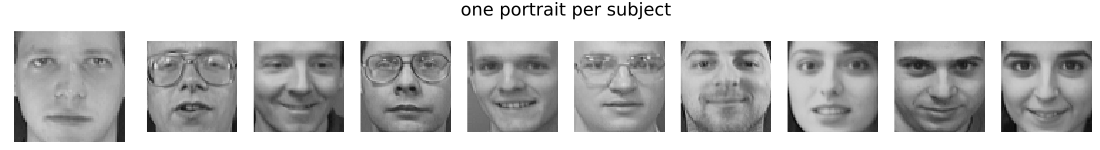

In [5]:
let
    one_per_subject = hcat([X[:, findfirst(==(s), y)] for s in 0:(n_subjects - 1)]...)
    image_grid(one_per_subject, n_subjects; title = "one portrait per subject")
end

### Build the SA models and reference classifier
We construct three Julia objects that the rest of the notebook will reuse:

* `sa_gen::MyStochasticAttentionModel`, the SA sampler at $\beta_{\mathrm{gen}}$ used by Task 1 (unconditional novel-face generation).
* `sa_cond::MyStochasticAttentionModel`, the SA sampler at $\beta_{\mathrm{cond}}$ used by Task 2 (subject-conditional generation, hard-mask vs. soft-bias).
* `class_means::Dict{Int, Vector{Float64}}`, the per-subject centroid of the stored portraits. Used by Task 2 as a deterministic, training-free reference classifier.

The factory functions live in [`src/Factory.jl`](src/Factory.jl); see [`src/Types.jl`](src/Types.jl) for the structs they populate.


In [6]:
sa_gen, sa_cond, class_means = let

    # initialize -
    sa_gen = nothing;
    sa_cond = nothing;
    class_means = nothing;

    # build the unconditional SA sampler (Task 1) -
    sa_gen = build(MyStochasticAttentionModel, (
        memories     = X,
        labels       = y,
        β            = β_gen,
        step_size    = 1.0,  # TODO: try 0.25, 0.5, 1.0
        noise_scale  = 0.10, # TODO: try 0.02 (regurgitation), 0.10, 0.30
    ));

    # build the masked / soft-bias SA sampler (Task 2) -
    sa_cond = build(MyStochasticAttentionModel, (
        memories     = X,
        labels       = y,
        β            = β_cond,
        step_size    = 1.0,
        noise_scale  = 0.10,
    ));

    # compute the per-subject means for later evaluation -
    class_means = build_class_means(X, y);

    # return -
    sa_gen, sa_cond, class_means;
end

(MyStochasticAttentionModel([0.294118 0.431373 … 0.094118 0.380392; 0.32549 0.423529 … 0.117647 0.403922; … ; 0.156863 0.129412 … 0.52549 0.141176; 0.14902 0.145098 … 0.52549 0.145098], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  9, 9, 9, 9, 9, 9, 9, 9, 9, 9], 0.02, 1.0, 0.1), MyStochasticAttentionModel([0.294118 0.431373 … 0.094118 0.380392; 0.32549 0.423529 … 0.117647 0.403922; … ; 0.156863 0.129412 … 0.52549 0.141176; 0.14902 0.145098 … 0.52549 0.145098], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  9, 9, 9, 9, 9, 9, 9, 9, 9, 9], 8.0, 1.0, 0.1), Dict(0 => [0.3239217, 0.3235293, 0.33058820000000005, 0.3278432, 0.33607829999999994, 0.33999999999999997, 0.34823540000000003, 0.3388233, 0.33529390000000003, 0.3482351  …  0.3019609, 0.30039210000000005, 0.29333320000000007, 0.2713725, 0.2627453, 0.26666660000000003, 0.26784320000000006, 0.2674509, 0.2631374, 0.26274519999999996], 4 => [0.4713725999999999, 0.4658823999999999, 0.46235300000000007, 0.4678433, 0.4631371999999999, 0.4576469, 0.4513724999999999, 0.

## Task 1: Stochastic Attention Sampling on faces

**The question this task answers.** *Can adding a single Gaussian-noise term to the modern-Hopfield update — no training, no GPU, no learned weights — turn it into a generative model that produces new faces we never stored?*

Why this is an interesting question. Recall (from L15 / Ramsauer et al.) that the modern-Hopfield update is a content-addressable *recall* operation: it always returns one of the stored columns of $\mathbf{X}$ (in the high-$\beta$ limit, exactly one; at moderate $\beta$, a softmax mixture sharply concentrated on one). A recall loop, by construction, **cannot generate anything new**. The 100 stored Olivetti portraits are all you can ever get out. So a recall network is not a generative model.

Stochastic Attention (SA) of [Varner (2026, arXiv:2603.14717)](https://arxiv.org/abs/2603.14717) makes a one-line change to the update — it adds Gaussian noise — and *claims* that this turns the same machinery into a sampler for a face-shaped distribution:

$$\underbrace{\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t})}_{\text{modern-Hopfield update from Task 1 (η-blended)}} \;+\; \underbrace{\sigma\cdot\boldsymbol{\xi}_{t}}_{\text{the new term}},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$

The reinterpretation is that the modern-Hopfield log-sum-exp energy $E_{\beta}(\mathbf{s}) = -\tfrac{1}{\beta}\log\!\sum_{j} \exp\!\big(\beta\cdot\mathbf{X}_{:,j}^{\top}\mathbf{s}\big)$ defines a Boltzmann distribution $p_{\beta}(\mathbf{s}) \propto e^{-E_{\beta}(\mathbf{s})}$, the modern-Hopfield update is its score $\nabla_{\mathbf{s}}\log p_{\beta}(\mathbf{s})$, and the noise term turns gradient descent on $E_{\beta}$ into Langevin dynamics that samples from $p_{\beta}$. The pure Langevin SDE corresponds to $\sigma = \sqrt{2\eta/\beta}$, but we expose $\eta$ and $\sigma$ as independent knobs so you can probe the fidelity / novelty trade-off.

**Concretely, Task 2 answers the question with two passes:**

1. **Do the samples *look* like faces?** (Inspection.) Run 10 independent Langevin chains, each warm-started at a random stored portrait plus a kick, for $n_{\mathrm{steps}} = 3000$ steps. Plot the final 10 states as a grid. **What you should see:** 10 recognizable human faces, with visible *novelty* — features that are blends of multiple stored portraits — because the chain can settle into a convex blend of stored memories.
2. **Are they actually new, or just stored portraits in disguise?** (Quantitative novelty check, further down.) For each generated sample, compute its Euclidean distance to the *nearest* stored Olivetti portrait; compare the median of those distances to the typical pairwise distance between stored portraits. **If `nearest-stored ≈ pairwise`, the samples sit at "normal inter-portrait distance" away from the training set — they are genuinely new faces.** If `nearest-stored ≈ 0`, the chain is regurgitating; the noise term is too small to escape the basin of its starting memory.

The chain inspector in between ("start vs. final after 3000 steps") is a sanity check that the noise term is *doing real work* — a chain that just sits on its starting portrait would mean $\sigma$ is too small or $\beta$ is too large.

**Inputs / outputs of the simulation:**
* In: `sa_gen` (built once in Setup with the values you set there — $\beta_{\mathrm{gen}} = 0.02$, $\eta = 1$, $\sigma = 0.10$); `n_samples_unmasked::Int`; warm-start matrix `unmasked_initial::Matrix{Float64}` of shape $4096 \times n$ from `sa_initial_states`; number of Langevin steps `n_steps`.
* Out: `unmasked_samples::Matrix{Float64}` of shape $4096 \times n$ — one *generated* face per column. To experiment with different $\eta$ or $\sigma$, change them in the Setup section and re-run from there.

__Generate samples__. The cell below runs Task 2's first simulation — it builds the warm-start matrix, runs 3000 Langevin steps per chain, and stores the results in `unmasked_samples`.


In [7]:
n_samples_unmasked, unmasked_initial, unmasked_samples = let

    # initialize -
    n_samples_unmasked = 10;

    # build the warm-start matrix EXPLICITLY so we can show start vs final per chain.
    # Each column is a random stored portrait plus a small Gaussian kick.
    unmasked_initial = sa_initial_states(sa_gen, n_samples_unmasked);

    # run n_steps Langevin steps starting from unmasked_initial. At β_gen = 0.02
    # the softmax is soft enough that the chain mixes between portraits, so the
    # final noise-free read-out (denoise = true) returns a clean blend of memories
    # rather than collapsing onto a single stored portrait.
    unmasked_samples = stochastic_attention_sample(sa_gen, n_samples_unmasked;
        n_steps = 3000, sₒ = unmasked_initial);

    # return -
    n_samples_unmasked, unmasked_initial, unmasked_samples;
end

(10, [0.22042986077871146 0.13330814801966512 … 0.6734212802518158 0.1713906961953948; 0.1920936014415522 0.24691973406941894 … 0.7574860696722592 0.17967447760318317; … ; 0.16737663595886795 0.24031238877872071 … 0.16619744887025378 0.4570020818883412; 0.12734313669334574 0.19837289244582876 … 0.17197793816636056 0.5069373784735727], [0.5070576425525991 0.5065882050878556 … 0.5069065262561164 0.5049498330392269; 0.5064185000786012 0.5058836339369156 … 0.5061977648414028 0.5042947425747202; … ; 0.6180414662148616 0.6170797774192334 … 0.6181466084048549 0.6176705742346561; 0.6211399069773631 0.6201476956347562 … 0.6212068447589437 0.6207662883402141])

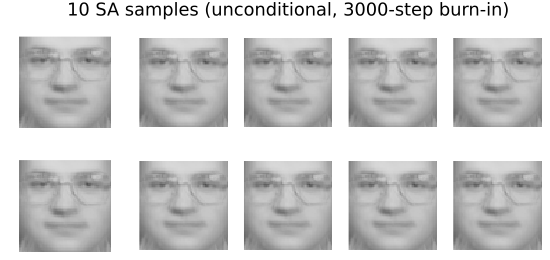

In [8]:
image_grid(unmasked_samples, 5; title = "$(n_samples_unmasked) SA samples (unconditional, 3000-step burn-in)")

__Chain inspector__: pick a chain index in `1:n_samples_unmasked` and we show its **starting state** (a random stored portrait plus a small Gaussian kick — the warm-start of that Langevin chain) next to **where the chain ended up** after `n_steps = 3000` updates. Use this to confirm the chain actually *moved*: a healthy SA chain settles between portraits rather than snapping straight back to its starting image. Try a few different `chain_index` values to get a sense of the typical motion.


unconditional · chain 1


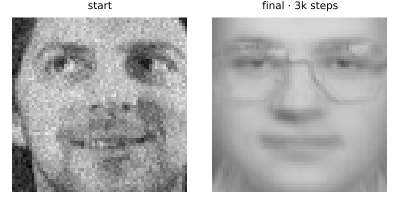

In [9]:
chain_index = let
    chain_index = 1; # TODO: pick a chain index in 1:n_samples_unmasked
    @assert 1 <= chain_index <= n_samples_unmasked
    chain_index;
end
println("unconditional · chain $chain_index")

let
    grid = hcat(unmasked_initial[:, chain_index], unmasked_samples[:, chain_index])
    image_grid(grid, 2; tile_px = 200,
        tile_titles = ["start", "final · 3k steps"])
end

__Novelty check__. The cell below quantifies the visual claim above. It computes two numbers:

* **median nearest-stored distance for SA samples**: for each of the generated samples, find its closest stored portrait in Euclidean distance, then take the median across samples. This is how *far* a typical generated sample sits from the training set.
* **median pairwise distance among stored portraits**: the median Euclidean distance between pairs of stored Olivetti portraits. This is the natural "unit of novelty" — the typical separation between two faces in the training set itself.

**How to read the numbers:**
* If `nearest-stored ≪ pairwise`, the sampler is producing copies (or near-copies) of stored portraits — **regurgitation mode**, raise $\sigma$ or lower $\beta$.
* If `nearest-stored ≈ pairwise`, generated samples sit at typical inter-portrait distance from stored memories — they are genuinely novel faces.
* If `nearest-stored ≫ pairwise`, the chains have wandered off the data manifold entirely — too much noise; samples will not look like faces.


In [10]:
let
    nearest_dist = Float64[]
    for k in 1:size(unmasked_samples, 2)
        s = unmasked_samples[:, k]
        push!(nearest_dist, minimum(norm(s .- X[:, j]) for j in 1:size(X, 2)))
    end
    Nstored = size(X, 2)
    pairs_n = min(50, Nstored)
    pairwise_sample = [norm(X[:, i] .- X[:, j]) for i in 1:pairs_n for j in (i + 1):pairs_n]
    println("median nearest-stored distance for SA samples: $(round(median(nearest_dist), digits=3))")
    println("median pairwise distance among stored portraits: $(round(median(pairwise_sample), digits=3))")
end

median nearest-stored distance for SA samples: 3.157
median pairwise distance among stored portraits: 10.394


### Discussion
1. Run Task 1 a few times with different combinations of $\beta$, `step_size`, and `noise_scale`. In particular: what happens to the generated faces as $\beta$ grows large (say `64`)? What happens as `noise_scale` grows large (say `0.5`)? Sketch the trade-off; there should be a sweet spot where samples *look* like faces but are not copies of the training set. Explain why this trade-off exists in terms of the SA energy landscape (think about the depth and width of the energy basins around stored portraits at different $\beta$).

Record your answer below and set `did_I_answer_DQ1::Bool` to `true`.


In [11]:
# -- Put your DQ1 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ1 = false; # TODO: update the flag value {true | false}

___

## Task 2: Subject-conditional generation by masking the softmax

**The claim we're testing.** In Task 1 the SA sampler treated every stored memory equally — chains could settle into any of the 100 stored Olivetti portraits and the resulting samples were a mix of all `n_subjects` people. We now want to *steer* generation: "give me a portrait of subject 7". The key idea is that the Boltzmann distribution over states is fully determined by the softmax over stored memories, so to **condition** the sampler on a subject we only need to change the **softmax logits** — the body of the chain stays identical.

We test two ways of doing this and compare them:

1. **Hard mask** (this section, expected to work cleanly). Set the logit of every off-subject memory to $-\infty$:
   $$\mathrm{logit}_{j} \;=\; \beta\cdot\mathbf{X}_{:,j}^{\top}\mathbf{s} \;+\; \begin{cases} 0 & \text{if }y_{j} = \text{target} \\ -\infty & \text{otherwise}\end{cases}$$
   The exponential then sends every off-subject entry to exactly $0$, so the softmax distribution lives entirely on the in-subject portraits. The chain *cannot* visit an off-subject attractor — same trick GPT uses for causal masking, applied to a Hopfield memory.
2. **Soft bias** (next section, the calibration-gap demo). Add a finite scalar bonus $b$ to in-subject logits and leave off-subject logits alone. With a huge $b$ the soft version approaches the hard mask; at $b = 0$ it reduces to the unconditional sampler. The interesting question is what happens *in between*. [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows that even at very large $b$ the soft version can fail to reach the hard-mask hit rate — the **calibration gap**.

**Inputs and outputs (this section).** What you give the masked sampler:
* `sa_cond` — a fresh SA model built at $\beta_{\mathrm{cond}} = 8$ in the Setup section (same $\mathbf{X}$, $y$ as `sa_gen`, but a sharper $\beta$ so the calibration gap is visible). **No retraining; no rebuilding.** The mask is a single `Vector{Bool}` of length $N$ passed at sample time.
* `target_class::Int` $\in 0..\texttt{n\_subjects}-1$ — which subject id you want.
* `class_mask::Vector{Bool}` of length $N$ — `class_mask[j] = (y[j] == target_class)`. This is the boolean **keep-mask**: `true` means "this portrait is allowed", `false` means "this portrait is forbidden".
* `n_samples_class::Int` — how many chains to run for this subject.
* (under the hood) Each chain is initialized as `(X[:,j_random] + small noise)` for a *random in-subject* `j`, then run for $n_{\mathrm{steps}} = 3000$ Langevin updates with the masked softmax, then a final noise-free read-out step.

What you get back: `class_samples::Matrix{Float64}` of shape $4096 \times n_{\mathrm{samples\_class}}$ — one generated portrait per column, each one a convex blend of stored target-subject portraits (because the mask blocks every off-subject attractor).

**How we'll show it (three simulations in this section):**
1. **Generate one batch of target-subject samples** and look at them as a grid. Pick `target_class`, build `class_mask`, run the sampler, plot the generated portraits. **What you should see:** all of them should look like the requested subject (with stylistic variation — different stored shots blended together).
2. **Chain inspector** (next markdown cell). For a chosen chain, show its starting image (a random in-subject stored portrait, plus a kick) next to its final state after 3000 Langevin steps, so you can see the *trajectory* of one chain. **What you should see:** the start is a recognizable in-subject portrait; the final is a slightly different in-subject portrait (the chain has mixed across in-subject memories) — but both are clearly the same person.
3. **Hit-rate table** (Fidelity check section). To turn "looks like subject 7" into a number, classify each sample by its nearest per-subject centroid and report the fraction that maps back to `target_class`. **What you should see:** hit rates well above $0.7$ for every subject — the hard mask works.


In [12]:
target_class, n_samples_class, class_mask = let

    # initialize -
    target_class = 2;          # TODO: which subject id to generate (0..n_subjects-1)
    n_samples_class = 10;      # TODO: how many samples per subject (note: only $images_per_subject stored portraits per subject)
    class_mask = [yj == target_class for yj in y];
    println("class_mask leaves ", count(class_mask), " of ", length(class_mask), " stored portraits visible")

    # return -
    target_class, n_samples_class, class_mask;
end

class_mask leaves 10 of 100 stored portraits visible


(2, 10, Bool[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
class_initial, class_samples = let

    # build the warm-start matrix EXPLICITLY (drawn only from in-subject memories
    # because we pass hard_mask = class_mask) so we can show start vs final per chain.
    class_initial = sa_initial_states(sa_cond, n_samples_class; hard_mask = class_mask);

    # generate the subject-conditional samples via the hard mask, starting from class_initial -
    class_samples = stochastic_attention_sample(sa_cond, n_samples_class;
        n_steps = 3000, hard_mask = class_mask, sₒ = class_initial);

    # return -
    class_initial, class_samples;
end

([0.17756334744988075 0.5353444334268237 … 0.13271429561943338 0.5532376919319468; 0.1570075901325611 0.469666981516477 … 0.20345538128478635 0.4837697906041762; … ; 0.19868327810941605 0.13635713915978465 … 0.18516655227767007 0.261062282520701; 0.17875876745015992 0.21989351684089464 … 0.10120956543696918 0.22241169111631284], [0.494118 0.494118 … 0.494118 0.5137249999999999; 0.462745 0.462745 … 0.462745 0.49803899999999984; … ; 0.203922 0.203922 … 0.203922 0.207843; 0.192157 0.192157 … 0.192157 0.21568599999999988])

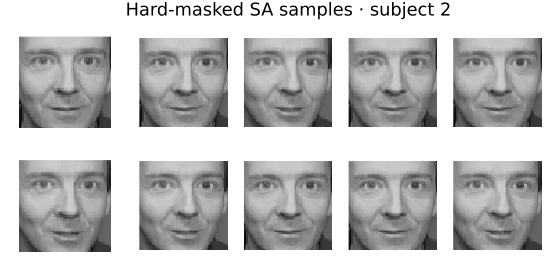

In [14]:
image_grid(class_samples, 5;
    title = "Hard-masked SA samples · subject $(target_class)")

__Chain inspector (masked)__: pick a chain index in `1:n_samples_class` and we show its **starting state** (a random in-subject stored portrait plus a small Gaussian kick) next to **where the chain ended up** after 3000 masked Langevin steps. Because every off-subject memory has logit $-\infty$, the chain is *trapped* on the in-subject region of the energy landscape — both tiles should be the requested subject, but the final tile should differ from the start (showing that the chain mixed across in-subject portraits rather than just regurgitating its starting image).


subject 2 · chain 1


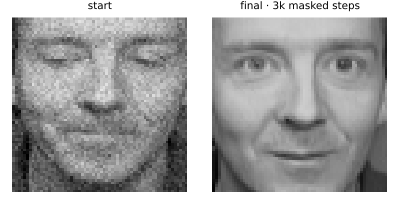

In [15]:
class_chain_index = let
    class_chain_index = 1; # TODO: pick a chain index in 1:n_samples_class
    @assert 1 <= class_chain_index <= n_samples_class
    class_chain_index;
end
println("subject $target_class · chain $class_chain_index")

let
    grid = hcat(class_initial[:, class_chain_index], class_samples[:, class_chain_index])
    image_grid(grid, 2; tile_px = 200,
        tile_titles = ["start", "final · 3k masked steps"])
end

### Fidelity check
We want a deterministic, training-free way to ask "did this generated sample look like the target subject?" The cheapest classifier is the **nearest-mean classifier**: label a sample by its closest per-subject centroid in pixel space. The centroids `class_means::Dict{Int, Vector{Float64}}` were precomputed in the Setup section.

We loop over all `n_subjects` subjects, draw `n_samples_class` samples each under the hard mask, and report the fraction that the nearest-mean classifier maps back to the requested subject. A perfect hard mask should give very high fractions across the board.

The code below stores the per-subject hit-rate table in `hardmask_table::DataFrame` for use in subsequent cells.


In [16]:
hardmask_table = let
    df = DataFrame(target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    for c in 0:(n_subjects - 1)
        m = [yj == c for yj in y]
        samples = stochastic_attention_sample(sa_cond, n_samples_class;
            n_steps = 3000, hard_mask = m)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(c), labels)
        push!(df, (target = c, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end
    pretty_table(df)
    df
end;

┌────────┬───────┬───────┬──────────┐
│ target │  hits │ total │ hit_rate │
│  Int64 │ Int64 │ Int64 │  Float64 │
├────────┼───────┼───────┼──────────┤
│      0 │    10 │    10 │      1.0 │
│      1 │    10 │    10 │      1.0 │
│      2 │    10 │    10 │      1.0 │
│      3 │    10 │    10 │      1.0 │
│      4 │    10 │    10 │      1.0 │
│      5 │    10 │    10 │      1.0 │
│      6 │    10 │    10 │      1.0 │
│      7 │     9 │    10 │      0.9 │
│      8 │    10 │    10 │      1.0 │
│      9 │     0 │    10 │      0.0 │
└────────┴───────┴───────┴──────────┘


### Hard mask vs. soft bias: the calibration gap
A hard mask zeros out off-subject logits exactly. A soft bias instead adds a finite scalar bonus to in-subject logits and leaves off-subject logits in play. With a large bias the soft version approaches the hard version; at zero bias it reduces to the unconditional sampler. In between, the soft version interpolates between the two **in attention space**; but, as [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows, that interpolation does not always land where you would naively expect in pixel space. The discrepancy is the **calibration gap**, and it is much more visceral on faces than on digits — a soft-biased sample that looks like the wrong person is *immediately* obvious.

We sweep the bias and see what happens.

The code below stores the bias-versus-hit-rate table in `softbias_table::DataFrame` for use in subsequent cells.


In [17]:
softbias_table = let
    df = DataFrame(bias = Float64[], target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    in_class = [yj == target_class for yj in y]
    for b in [0.0, 1.0, 5.0, 20.0, 100.0]
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        samples = stochastic_attention_sample(sa_cond, n_samples_class;
            n_steps = 3000, soft_bias = sb_vec)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(target_class), labels)
        push!(df, (bias = b, target = target_class, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end
    pretty_table(df)
    df
end;

┌─────────┬────────┬───────┬───────┬──────────┐
│    bias │ target │  hits │ total │ hit_rate │
│ Float64 │  Int64 │ Int64 │ Int64 │  Float64 │
├─────────┼────────┼───────┼───────┼──────────┤
│     0.0 │      2 │     0 │    10 │      0.0 │
│     1.0 │      2 │     0 │    10 │      0.0 │
│     5.0 │      2 │     0 │    10 │      0.0 │
│    20.0 │      2 │     0 │    10 │      0.0 │
│   100.0 │      2 │     0 │    10 │      0.0 │
└─────────┴────────┴───────┴───────┴──────────┘


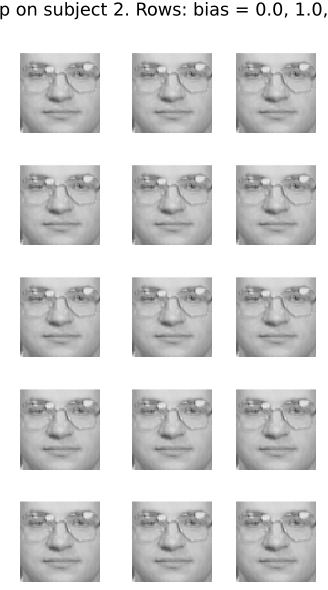

In [18]:
# Visualize one batch from each bias setting side-by-side at the fixed target subject.
let
    biases = [0.0, 1.0, 5.0, 20.0, 100.0]
    n_per = 3
    grid_cols = Vector{Vector{Float64}}()
    in_class = [yj == target_class for yj in y]
    for b in biases
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        s = stochastic_attention_sample(sa_cond, n_per; n_steps = 3000, soft_bias = sb_vec)
        for k in 1:n_per
            push!(grid_cols, s[:, k])
        end
    end
    G = reduce(hcat, grid_cols)
    image_grid(G, n_per; title = "Soft-bias sweep on subject $(target_class). Rows: bias = " * join(string.(biases), ", "))
end

### Discussion
2. Compare the hard-mask hit-rate table with the soft-bias hit-rate table.
   * For a bias just above zero, the hit rate barely moves; for very large bias, it climbs toward the hard-mask value. Why is this? Think about the magnitude of the inner-product term $\beta\cdot\mathbf{X}^{\top}\mathbf{s}$ versus the additive bias.
   * Even at bias = 100, the soft-bias version may not reach 100% hit rate, while the hard mask does. What is being lost? Connect this to the **calibration gap** of [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115): the conditioning is exact at the level of the sampler's softmax weights, but the *decoded* sample can disagree because the inner-product term steers the chain toward whichever attractor is closest to the current state, regardless of subject.

Record your answer below and set `did_I_answer_DQ1::Bool` to `true`.


In [19]:
# -- Put your DQ2 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ2 = false; # TODO: update the flag value {true | false}

## Task 3: $\beta$-sweep — the Hebbian/Hopfield bridge under a mask

**The claim we're testing.** The intro asserted that the modern-Hopfield update interpolates between two regimes via $\beta$: at low $\beta$ the softmax is broad and recall returns a *blend* of stored memories; at high $\beta$ it collapses to a single stored column — the **Hebbian limit**, exactly the L15 H-Mem read step. So far in this practicum that has been a *narrative* claim. Task 3 turns it into a measurement.

**Setup.** We hold the subject mask, the chain length, and the noise schedule fixed at the Task 2 settings. The *only* knob we sweep is $\beta_{\mathrm{cond}}$, across a logarithmic grid from very soft to very sharp. For each $\beta$ we build a fresh `MyStochasticAttentionModel` over the same memory bank `X`, run masked Langevin chains for the target subject, and compute two diagnostics on the generated samples:

* **Hit rate via nearest-mean classifier**, the same fidelity score we used in Task 2. Because the hard mask blocks every off-subject memory regardless of $\beta$, hit rate should stay high across the entire sweep — the *mask*, not $\beta$, is what enforces conditioning.
* **Median nearest-stored distance** $\min_{j}\|\mathbf{s} - \mathbf{X}_{:,j}\|$. This is our novelty proxy from Task 1. At low $\beta$, the masked softmax is nearly uniform over in-subject memories, so the chain settles near a *convex blend* of stored portraits — distance from any single stored portrait stays moderate. At high $\beta$ the softmax concentrates on whichever in-subject memory is closest to the current state, and one denoised read-out collapses the chain back onto exactly that stored column — distance to nearest-stored should fall toward $0$. **The shape of that distance-vs-$\beta$ curve is the bridge:** the smooth left-to-right descent recovers the modern-Hopfield $\to$ Hebbian transition empirically.

**What you should see.**
1. Hit rate is roughly flat (and high) across the sweep — the mask alone handles conditioning.
2. Median nearest-stored distance is a decreasing function of $\beta$. At $\beta \lesssim 10^{-2}$ the chain is dominated by the soft mean; at $\beta \gtrsim 10^{2}$ it has collapsed to stored portraits (Hebbian recall). The transition happens smoothly across the middle of the grid.

**Inputs / outputs.**
* In: `X`, `y`, `target_class`, `class_mask`, `n_samples_class`, `class_means` (all from earlier cells); the sweep grid `β_grid`.
* Out: `bridge_table::DataFrame` with one row per $\beta$ value, columns `β`, `hit_rate`, `median_nearest_stored`. We also keep `bridge_samples_low` and `bridge_samples_high` (the actual sample matrices at the smallest and largest $\beta$) so the discussion can show two extremes side-by-side.


In [ ]:
β_grid, bridge_table, bridge_samples_low, bridge_samples_high = let

    # initialize -
    β_grid = [0.005, 0.02, 0.1, 0.5, 2.0, 8.0, 32.0, 128.0]; # TODO: try a denser or wider grid
    df = DataFrame(β = Float64[], hit_rate = Float64[], median_nearest_stored = Float64[])
    bridge_samples_low  = nothing
    bridge_samples_high = nothing

    # sweep β with everything else fixed -
    for (i, β) in enumerate(β_grid)
        sa_β = build(MyStochasticAttentionModel, (
            memories     = X,
            labels       = y,
            β            = β,
            step_size    = sa_cond.step_size,
            noise_scale  = sa_cond.noise_scale,
        ))
        samples = stochastic_attention_sample(sa_β, n_samples_class;
            n_steps = 3000, hard_mask = class_mask)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        hit_rate = count(==(target_class), labels) / n_samples_class
        nearest = [minimum(norm(samples[:, k] .- X[:, j]) for j in 1:size(X, 2))
                   for k in 1:n_samples_class]
        push!(df, (β = β, hit_rate = hit_rate, median_nearest_stored = median(nearest)))
        i == 1                && (bridge_samples_low  = samples)
        i == length(β_grid)   && (bridge_samples_high = samples)
    end
    pretty_table(df)

    # return -
    β_grid, df, bridge_samples_low, bridge_samples_high;
end;

In [ ]:
# Two-panel diagnostic: hit rate (flat) and novelty (descending) vs β.
let
    p1 = plot(bridge_table.β, bridge_table.hit_rate;
        xscale = :log10, marker = :circle, lw = 2, ylim = (0.0, 1.05),
        xlabel = "β (log scale)", ylabel = "hit rate",
        label = "subject $(target_class)", title = "Hit rate vs β (mask handles conditioning)")
    p2 = plot(bridge_table.β, bridge_table.median_nearest_stored;
        xscale = :log10, marker = :circle, lw = 2,
        xlabel = "β (log scale)", ylabel = "median nearest-stored distance",
        label = "subject $(target_class)",
        title = "Novelty vs β (modern-Hopfield → Hebbian)")
    plot(p1, p2; layout = (1, 2), size = (1000, 380))
end

In [ ]:
# Visual: the low-β end of the sweep — soft blends of in-subject portraits.
image_grid(bridge_samples_low, 5;
    title = "Low β = $(β_grid[1]) — soft blends (modern-Hopfield mean)")

In [ ]:
# Visual: the high-β end of the sweep — Hebbian recall onto stored portraits.
image_grid(bridge_samples_high, 5;
    title = "High β = $(β_grid[end]) — near-replicas of stored portraits (Hebbian limit)")

### Discussion
3. Look at the **hit rate** column of `bridge_table` versus the **median_nearest_stored** column.
   * Hit rate is roughly flat and high across the entire $\beta$-grid — even at $\beta = 0.005$ where the softmax is nearly uniform. Why does conditioning still hold? Connect this to which mechanism is actually doing the conditioning work in the masked sampler.
   * Median nearest-stored distance is monotone decreasing in $\beta$ and approaches $0$ at the high end. Read this curve as the empirical version of the bridge claim from the intro: at low $\beta$ the SA sample is a soft *blend* of in-subject portraits (modern-Hopfield mean); at high $\beta$ it has collapsed to a single stored portrait — the **Hebbian recall** of L15. Where on your grid does the transition happen, and how would you describe the regime in the middle?
   * Compare the two extreme image grids above. The low-$\beta$ grid should show face-like *blends* of multiple stored portraits of `target_class`; the high-$\beta$ grid should show near-replicas of stored portraits.

Record your answer below and set `did_I_answer_DQ3::Bool` to `true`.


In [ ]:
# -- Put your DQ3 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ3 = false; # TODO: update the flag value {true | false}

## Fun (totally optional) directions we could go with this idea
This was a proof-of-concept exploration of masked Stochastic Attention on the Olivetti faces. Real applications are well beyond image-based portraits, and the three papers below (all of which were born from this class) sketch where the idea goes next.

### Maybe a different application?
* __Small protein families__. A small alignment of <100 sequences from a single Pfam family is exactly the regime where deep generative models overfit, but where Stochastic Attention has linear-in-alignment-size cost on a laptop. See [Varner, *Training-Free Generation of Protein Sequences from Small Family Alignments via Stochastic Attention*, arXiv:2603.14717](https://arxiv.org/abs/2603.14717).
* __Conditioning on a binding screen__. If you have a small functional subset of a family (say, hits from a binding screen) and want to bias generation toward proteins that share that property, the multiplicity-weighted soft bias of this practicum's **Task 2** is exactly the recipe; see [Varner, *Conditioning Protein Generation via Hopfield Pattern Multiplicity*, arXiv:2603.20115](https://arxiv.org/abs/2603.20115). The same paper diagnoses the calibration-gap phenomenon you saw in DQ2.
* __Synthetic patient cohorts__. Replacing "stored protein sequence" with "stored longitudinal patient record" lets SA augment small clinical cohorts of <30 patients in domains like pregnancy and rare disease without retraining. See [Varner, Bravo, McBride, Orfeo, Bernstein, *Validated Synthetic Patient Generation for Small Longitudinal Cohorts*, arXiv:2604.07557](https://arxiv.org/abs/2604.07557).

### Other things to try
* __Causal mask__: instead of masking by class, set up a causal mask (`mask[j] = (j ≤ t)` at time step `t`) so the chain only attends to "earlier" memories, a Hopfield analogue of GPT's autoregressive generation.
* __Different inverse temperatures inside vs. outside the mask__: replace the scalar $\beta$ with a vector of per-pattern temperatures. This decouples *how confident* the sampler is about each memory from *which* memories are visible.
* __Compare to the spiking H-Mem of L15b__. The hard-mask SA produces a class-conditional generator from a static memory; the spiking H-Mem produces one-shot recall from a dynamically-written memory. Sketch how you would turn one into the other.

___

## Summary
This practicum took the modern-Hopfield retrieval rule of Ramsauer et al. (2020) — itself the high-temperature generalization of the H-Mem read step from L15 — and added a Langevin noise term to turn it into a training-free generative sampler over the Olivetti faces dataset. We then introduced a single boolean mask on the attention softmax as a route to subject-conditional generation, with a soft-bias variant for comparison, and finally swept the inverse temperature inside the masked sampler to recover the Hebbian/Hopfield bridge empirically.

## Key Takeaways
* **Stochastic Attention generates novel faces without training:** Injecting Gaussian noise into the modern-Hopfield update produces a Langevin-style sampler whose stationary distribution is the Hopfield Boltzmann measure over stored memories. Cost is linear in the number of stored portraits, and the sampler runs on a laptop with no gradient descent and no tuned weights. The temperature $\beta$ has to be tuned to the *dimensionality* of the data; on 4096-dim portraits, $\beta = 0.02$ keeps the softmax soft enough that the chain mixes between memories.
* **Hard masks condition cleanly while soft biases do not:** A boolean mask over the attention softmax delivers near-perfect subject-conditional generation by exactly excluding off-subject memories. A finite scalar bias on in-subject logits steers attention but rarely overcomes the inner-product term that dominates the softmax, leaving a calibration gap between attention-space conditioning and pixel-space output. The gap is visceral on faces — a soft-biased "Subject 7" sample that comes back as Subject 12 is *immediately* obvious to the eye in a way digit confusion never is.
* **The $\beta$-sweep recovers the modern-Hopfield $\to$ Hebbian bridge inside the masked sampler:** Holding the mask and noise fixed, hit rate is essentially flat across the sweep (the *mask* is what conditions, not $\beta$), but the median nearest-stored distance falls smoothly from "soft blend of in-subject portraits" at low $\beta$ to "near-replica of a stored portrait" at high $\beta$. The high-$\beta$ end is the L15 H-Mem read step in disguise; the low-$\beta$ end is the soft averaging of modern Hopfield. The bridge claim is no longer narrative — it is a curve.
___

## Tests
In the code block below, we check some values in your notebook and give you feedback on which items are correct or different. Unhide the code block (if you are curious) to see how the tests are set up.

In [20]:
let
    @testset verbose = true "CHEME 5820 Practicum S2026" begin

        @testset "Setup, Data, and Prerequisites" begin
            @test _DID_INCLUDE_FILE_GET_CALLED == true
            @test isnothing(n_subjects) == false
            @test isnothing(images_per_subject) == false
            @test isnothing(β_gen) == false
            @test isnothing(β_cond) == false
            @test β_gen > 0
            @test β_cond > 0
            @test size(X, 1) == 4096
            @test size(X, 2) == n_subjects * images_per_subject
            @test length(y) == size(X, 2)
            @test sort(unique(y)) == collect(0:(n_subjects - 1))
            @test isnothing(sa_gen) == false
            @test sa_gen.β == β_gen
            @test isnothing(sa_cond) == false
            @test sa_cond.β == β_cond
            @test sa_gen.step_size > 0
            @test sa_gen.noise_scale >= 0
            @test isnothing(class_means) == false
            @test length(class_means) == n_subjects
        end

        @testset "Task 1: Stochastic Attention sampling on faces" begin
            @test size(unmasked_initial) == (4096, n_samples_unmasked)
            @test size(unmasked_samples) == (4096, n_samples_unmasked)
            @test all(isfinite, unmasked_initial)
            @test all(isfinite, unmasked_samples)
            @test isnothing(chain_index) == false
            @test 1 <= chain_index <= n_samples_unmasked
            @test did_I_answer_DQ1 == true
        end

        @testset "Task 2: Masked SA = subject-conditional generation" begin
            @test 0 <= target_class <= n_subjects - 1
            @test length(class_mask) == size(X, 2)
            @test count(class_mask) == count(==(target_class), y)
            @test size(class_initial) == (4096, n_samples_class)
            @test all(isfinite, class_initial)
            @test size(class_samples) == (4096, n_samples_class)
            @test isnothing(class_chain_index) == false
            @test 1 <= class_chain_index <= n_samples_class
            @test mean(hardmask_table.hit_rate) > 0.7
            @test mean(hardmask_table.hit_rate) > maximum(softbias_table.hit_rate)
            @test did_I_answer_DQ2 == true
        end

        @testset "Task 3: β-sweep recovers the Hebbian/Hopfield bridge" begin
            @test length(β_grid) >= 4
            @test issorted(β_grid)
            @test all(>(0), β_grid)
            @test nrow(bridge_table) == length(β_grid)
            @test all(isfinite, bridge_table.hit_rate)
            @test all(isfinite, bridge_table.median_nearest_stored)
            @test mean(bridge_table.hit_rate) > 0.7
            # bridge claim: novelty (distance to nearest stored) at the
            # smallest β should exceed novelty at the largest β — the
            # Hebbian-limit collapse onto stored portraits.
            @test bridge_table.median_nearest_stored[1] > bridge_table.median_nearest_stored[end]
            @test size(bridge_samples_low)  == (4096, n_samples_class)
            @test size(bridge_samples_high) == (4096, n_samples_class)
            @test did_I_answer_DQ3 == true
        end
    end
end;

Task 1: Stochastic Attention sampling on faces: Test Failed at /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1656sZmlsZQ==.jl:33
  Expression: did_I_answer_DQ1 == true
   Evaluated: false == true

Stacktrace:
 [1] top-level scope
   @ ~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1656sZmlsZQ==.jl:4
 [2] macro expansion
   @ ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Test/src/Test.jl:1777 [inlined]
 [3] macro expansion
   @ ~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1656sZmlsZQ==.jl:27 [inlined]
 [4] macro expansion
   @ ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Test/src/Test.jl:1777 [

Test.TestSetException: Some tests did not pass: 35 passed, 1 failed, 1 errored, 0 broken.